$$\Huge\textbf{⛽ Global Petrol Prices}$$

$$\Large\text{Impact of 2026 US-Iran War}$$

$$\rule{12cm}{0.4pt}$$

$$\large\textbf{Business Analytics Case Study}$$

$$\rule{12cm}{0.4pt}$$

$$\textbf{Dataset:} \quad \text{Kaggle} \ — \ \texttt{zkskhurram}$$

$$\textbf{Tools:} \quad \texttt{Python} \ | \ \texttt{Pandas} \ | \ \texttt{Matplotlib} \ | \ \texttt{Seaborn} \ | \ \texttt{Scikit-learn}$$

$$\textbf{Date:} \quad \text{March 2026}$$

$$\rule{12cm}{0.4pt}$$

## ⛽ Global Petrol Prices — Impact of 2026 US-Iran War

This notebook analyses how the **2026 US-Iranian military conflict** disrupted global petroleum prices across **14 countries** (Feb–Mar 2026). Following US-Israeli strikes on Iran (28 Feb 2026) and Iran's closure of the **Strait of Hormuz** — which carries ~20% of the world's oil supply — Brent crude surged from ~\$70 to over **\$104/barrel**, triggering cascading fuel price increases worldwide.

We explore **5 datasets** covering daily crude oil prices, a war event timeline, country-level economic impact, retail petrol comparisons, and a structured pros/cons analysis — using EDA, visualisation, linear regression, a vulnerability scorecard, and what-if scenario modelling.

---

| 🛢️ Brent Crude Peak | 📈 Highest Country Increase | 🌍 Countries Tracked | ⏱️ Events Logged |
|:---:|:---:|:---:|:---:|
| **\$104.25 / barrel** | **Pakistan +20.66%** | **17** | **20** |



## 📚 **Step 1: Import Libraries**
Importing all necessary libraries for data analysis and visualization.
- **pandas** → data manipulation
- **numpy** → mathematical calculations
- **matplotlib** → data visualization
- **seaborn** → statistical visualization

In [2]:
# Step 1: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 **Step 2: Load Dataset**
Downloading dataset directly from Kaggle using KaggleHub.
The dataset contains 5 CSV files tracking the impact of
the 2026 US-Iran War on global petrol prices across 14 countries.

In [3]:
# Step 2: Download dataset from Kaggle
import kagglehub
path = kagglehub.dataset_download("zkskhurram/global-petrol-prices-impact-of-2026-us-iran-war")
print("Files are saved at:", path)

100%|██████████| 8.04k/8.04k [00:00<00:00, 9.23MB/s]

Extracting files...
Files are saved at: /root/.cache/kagglehub/datasets/zkskhurram/global-petrol-prices-impact-of-2026-us-iran-war/versions/1


In [4]:
import os
os.listdir(path)

['pros_cons_analysis.csv',
 'country_impact.csv',
 'war_timeline.csv',
 'crude_oil_daily.csv',
 'README.md',
 'petrol_prices_comparison.csv']


## 🔍 **Step 3: Exploratory Data Analysis**
Exploring each dataset to understand structure, patterns and key insights.

**Datasets loaded in narrative order:**
- war_timeline.csv → What happened? (Cause)
- crude_oil_daily.csv → How did oil markets react?
- petrol_prices_comparison.csv → How did retail prices change?
- country_impact.csv → Which countries were hurt?
- pros_cons_analysis.csv → What were the consequences?

In [5]:
timeline=pd.read_csv(path + '/war_timeline.csv')
timeline.head()

,Date,Event,Description,Location,Category
0,2025-12-01,Protests,Widespread economic protests erupt across Iran...,Iran,Political
1,2025-12-15,Internet Shutdown,Iran government shuts down internet amid crack...,Iran,Political
2,2026-01-10,US Military Buildup,US bolsters military presence off Iran's coast...,USA / Iran,Military
3,2026-02-01,Geneva Talks Begin,Indirect US-Iran nuclear negotiations begin in...,Switzerland,Diplomatic
4,2026-02-25,Talks Collapse,Geneva nuclear negotiations end without breakt...,Switzerland,Diplomatic


In [6]:
timeline.shape

(20, 5)

In [7]:
timeline.columns

Index(['Date', 'Event', 'Description', 'Location', 'Category'], dtype='object')

In [8]:
# Check categories of events
timeline["Category"].value_counts()

,count
Category,
Economic,8
Energy,3
Political,3
Diplomatic,2
Military,2
Military/Energy,1
Social,1


In [9]:
crude=pd.read_csv(path+ '/crude_oil_daily.csv')
crude.head()

,Date,Brent_USD,WTI_USD,Brent_Change_Pct,WTI_Change_Pct,Phase,Strait_Hormuz
0,2026-02-16,74.2,70.1,0.00,0.00,Pre-Conflict,Open
1,2026-02-17,74.5,70.4,0.40,0.43,Pre-Conflict,Open
2,2026-02-18,75.1,71.0,0.81,0.85,Pre-Conflict,Open
3,2026-02-19,75.8,71.6,0.93,0.85,Pre-Conflict,Open
4,2026-02-20,76.0,71.8,0.26,0.28,Pre-Conflict,Open


In [10]:
crude.shape

(16, 7)

In [11]:
crude["Phase"].value_counts()

,count
Phase,
Pre-Conflict,10
Active Conflict,6


In [12]:
crude["Strait_Hormuz"].value_counts()

,count
Strait_Hormuz,
Open,10
Closed/Restricted,6


In [13]:
prices = pd.read_csv(path + "/petrol_prices_comparison.csv")
prices.head()

,Country,ISO,Region,Currency,Before_War_Price,Mar7_Price,Unit,Amount_Change,Pct_Increase,Trend,Before_War_USD,Mar7_USD,Oil_Import_Dep
0,Pakistan,PAK,South Asia,PKR,266.17,321.17,PKR/L,55.0,20.66,Increase,0.95,1.15,High
1,India,IND,South Asia,INR,94.77,94.77,INR/L,0.0,0.00,Stable,1.14,1.14,High
2,Bangladesh,BGD,South Asia,BDT,125.00,130.00,BDT/L,5.0,4.00,Increase,1.02,1.06,High
3,Afghanistan,AFG,South Asia,AFN,57.00,57.00,AFN/L,0.0,0.00,Stable,0.82,0.82,High
4,Nepal,NPL,South Asia,NPR,186.00,190.00,NPR/L,4.0,2.15,Increase,1.40,1.43,High


In [14]:
prices.shape

(14, 13)

In [15]:
prices["Country"]

,Country
0,Pakistan
1,India
2,Bangladesh
3,Afghanistan
4,Nepal
5,Sri Lanka
6,Turkey
7,Iran
8,Saudi Arabia
9,UAE


In [16]:
prices[["Country", "Pct_Increase"]].sort_values("Pct_Increase", ascending=False)

,Country,Pct_Increase
0,Pakistan,20.66
7,Iran,6.67
8,Saudi Arabia,6.45
13,USA,5.88
10,China,5.00
6,Turkey,4.88
9,UAE,4.62
2,Bangladesh,4.00
11,United Kingdom,3.93
12,Germany,3.85


In [17]:
impact = pd.read_csv(path + "/country_impact.csv")
print("Impact shape:", impact.shape)

Impact shape: (17, 10)


In [18]:
impact.head()

,Country,Region,Oil_Import_Pct,GDP_Impact_Pct,Inflation_Risk,Stock_Market_Change,Currency_Pressure,Policy_Response,Vulnerability,Population_M
0,Pakistan,South Asia,85,-1.8,Very High,-4.2,Severe,Emergency fuel price hike,Critical,240
1,India,South Asia,85,-1.2,High,-3.1,High,Strategic reserves released; prices frozen,High,1440
2,Bangladesh,South Asia,95,-2.0,Very High,-3.8,Severe,University closures to save electricity,Critical,175
3,Sri Lanka,South Asia,100,-2.5,Very High,-5.0,Severe,Rationing measures introduced,Critical,22
4,Nepal,South Asia,100,-1.5,High,-2.8,High,Price adjustment; subsidies for transport,High,30


In [19]:
pros = pd.read_csv(path + "/pros_cons_analysis.csv")
print("Pros/Cons shape:", pros.shape)

Pros/Cons shape: (16, 7)


In [20]:
pros.head()

,Category,Type,Title,Description,Impact_Level,Affected,Source
0,Economy,Con,Inflation Surge,Every 10% oil rise → 0.4% inflation increase &...,High,All countries,IMF
1,Economy,Con,Stagflation Risk,Combination of weak growth + high inflation th...,Critical,Global,FreightWaves
2,Economy,Con,Supply Chain Disruption,Higher transport costs cascade through all goo...,High,Global,Straits Financial
3,Economy,Pro,Oil Exporter Windfall,"Net oil exporters see increased revenues, inve...",Moderate,"Oil exporters (USA, Saudi, UAE)",Bison Interests
4,Environment,Pro,Accelerated Green Transition,"High prices incentivize renewable energy, EVs,...",Moderate,Global,Forbes/Climate Council


In [21]:
impact[["Country", "Oil_Import_Pct"]].sort_values(
    "Oil_Import_Pct", ascending=True)

,Country,Oil_Import_Pct
14,Iran,0
12,Saudi Arabia,0
13,UAE,0
11,USA,5
16,Egypt,40
10,United Kingdom,45
9,Germany,65
15,Australia,70
5,China,72
0,Pakistan,85


In [22]:
# Data Quality Check — verify no missing values
print("=" * 40)
print("DATA QUALITY CHECK")
print("=" * 40)
print(f"timeline nulls:  {timeline.isnull().sum().sum()}")
print(f"Crude nulls:     {crude.isnull().sum().sum()}")
print(f"Prices nulls:    {prices.isnull().sum().sum()}")
print(f"Impact nulls:    {impact.isnull().sum().sum()}")
print(f"Pros nulls:      {pros.isnull().sum().sum()}")
print("=" * 40)
print("✅ All datasets clean — ready for analysis!")

DATA QUALITY CHECK
timeline nulls:  0
Crude nulls:     0
Prices nulls:    0
Impact nulls:    0
Pros nulls:      0
✅ All datasets clean — ready for analysis!


$$\textbf{✅ Data Quality Result}$$

$$\text{All } \textbf{5 datasets} \text{ returned } \color{green}{\textbf{zero null values}}$$

$$\therefore \text{ No data cleaning or imputation required}$$

$$\text{All datasets are } \color{green}{\textbf{ready for analysis}}$$

$$\small\textit{(Source: All 5 CSV files)}$$

In [23]:
# Classify countries
def classify(pct):
    if pct == 0:
        return "Exporter"
    elif pct <= 70:
        return "Partial Importer"
    else:
        return "High Importer"

impact["Trade_Type"] = impact["Oil_Import_Pct"].apply(classify)

print(impact[["Country", "Oil_Import_Pct", "Trade_Type"]].sort_values(
    "Oil_Import_Pct", ascending=True))

           Country  Oil_Import_Pct        Trade_Type
14            Iran               0          Exporter
12    Saudi Arabia               0          Exporter
13             UAE               0          Exporter
11             USA               5  Partial Importer
16           Egypt              40  Partial Importer
10  United Kingdom              45  Partial Importer
9          Germany              65  Partial Importer
15       Australia              70  Partial Importer
5            China              72     High Importer
0         Pakistan              85     High Importer
1            India              85     High Importer
8           Turkey              89     High Importer
6            Japan              90     High Importer
7      South Korea              92     High Importer
2       Bangladesh              95     High Importer
4            Nepal             100     High Importer
3        Sri Lanka             100     High Importer


$$\textbf{Dataset Composition:}$$

$$\underbrace{3}_{\textbf{Exporters}} \quad \text{vs} \quad \underbrace{14}_{\textbf{High Importers}} \text{ — out of 17 tracked countries}$$

$$\because \text{ Majority are High Importers}$$

$$\therefore \text{ Hormuz closure had } \textbf{widespread global impact}$$

In [24]:
# Convert BOTH to datetime first
crude["Date"] = pd.to_datetime(crude["Date"])
timeline["Date"] = pd.to_datetime(timeline["Date"])

# Now merge works!
merged = pd.merge(crude, timeline[["Date", "Event", "Category"]],
                  on="Date", how="left")

print(merged[["Date", "Brent_USD", "Event"]].head(10))

        Date  Brent_USD           Event
0 2026-02-16       74.2             NaN
1 2026-02-17       74.5             NaN
2 2026-02-18       75.1             NaN
3 2026-02-19       75.8             NaN
4 2026-02-20       76.0             NaN
5 2026-02-23       76.3             NaN
6 2026-02-24       77.1             NaN
7 2026-02-25       78.5  Talks Collapse
8 2026-02-26       80.2             NaN
9 2026-02-27       82.0             NaN


$$\textbf{🔍 Merge Validation — War Timeline vs Crude Oil Prices}$$

$$\rule{12cm}{0.4pt}$$

$$\textbf{Pre-Conflict Phase:} \quad \text{Feb 16} \rightarrow \text{Feb 24}$$

$$\text{Brent Crude:} \quad \$74.20 \rightarrow \$77.10 \quad \color{orange}{\textbf{(+\$2.90 slow creep)}}$$

$$\rule{12cm}{0.4pt}$$

$$\textbf{First Trigger:} \quad \underbrace{\text{Feb 25 — Talks Collapse}}_{\color{orange}{\textbf{Diplomatic Failure}}} \Rightarrow \text{Brent} = \color{orange}{\$78.50}$$

$$\text{Next 2 days:} \quad \$78.50 \rightarrow \$82.00 \quad \color{red}{\textbf{(+\$3.50 in 2 days)}}$$

$$\rule{12cm}{0.4pt}$$

$$\textbf{NaN Events} \Rightarrow \text{Normal trading days with } \textbf{no major war event}$$

$$\therefore \text{Price was already } \color{red}{\textbf{rising}} \text{ before the first official event}$$

$$\Rightarrow \textbf{Markets anticipated conflict} \text{ before it was officially declared}$$

In [25]:
# Show all dates around conflict start
print(crude[["Date", "Brent_USD", "Phase"]].to_string())

         Date  Brent_USD            Phase
0  2026-02-16      74.20     Pre-Conflict
1  2026-02-17      74.50     Pre-Conflict
2  2026-02-18      75.10     Pre-Conflict
3  2026-02-19      75.80     Pre-Conflict
4  2026-02-20      76.00     Pre-Conflict
5  2026-02-23      76.30     Pre-Conflict
6  2026-02-24      77.10     Pre-Conflict
7  2026-02-25      78.50     Pre-Conflict
8  2026-02-26      80.20     Pre-Conflict
9  2026-02-27      82.00     Pre-Conflict
10 2026-03-02      85.30  Active Conflict
11 2026-03-03      88.60  Active Conflict
12 2026-03-04      92.70  Active Conflict
13 2026-03-05      95.00  Active Conflict
14 2026-03-06      97.80  Active Conflict
15 2026-03-09     104.25  Active Conflict


$$\textbf{📊 Crude Oil Price Analysis — Phase Breakdown}$$

$$\rule{12cm}{0.4pt}$$

$$\textbf{Phase 1:} \quad \underbrace{\text{Pre-Conflict}}_{\text{Feb 16 — Feb 27}} \quad \text{Brent:} \quad \$74.20 \rightarrow \$82.00$$

$$\color{orange}{\textbf{+\$7.80}} \text{ rise over 10 trading days} \quad \approx \color{orange}{\textbf{+10.5\%}}$$

$$\rule{12cm}{0.4pt}$$

$$\textbf{Phase 2:} \quad \underbrace{\text{Active Conflict}}_{\text{Mar 2 — Mar 9}} \quad \text{Brent:} \quad \$85.30 \rightarrow \$104.25$$

$$\color{red}{\textbf{+\$18.95}} \text{ rise over 6 trading days} \quad \approx \color{red}{\textbf{+22.2\%}}$$

$$\rule{12cm}{0.4pt}$$

$$\textbf{Weekend Gap:} \quad \text{Feb 27} \rightarrow \text{Mar 2} \quad \Delta = \color{red}{\textbf{+\$3.30}} \text{ (markets reopened higher)}$$

$$\rule{12cm}{0.4pt}$$

$$\textbf{Total Surge:} \quad \$74.20 \rightarrow \$104.25 \quad = \color{red}{\textbf{+\$30.05}} \approx \color{red}{\textbf{+40.5\%}}$$

$$\therefore \underbrace{\text{Active Conflict phase}}_{\color{red}{6 \text{ days}}} \text{ caused } \color{red}{\textbf{2.4}}\times \text{ more damage than } \underbrace{\text{Pre-Conflict phase}}_{\color{orange}{10 \text{ days}}}$$

In [26]:
# Phase summary — clean version
print(crude.groupby("Phase")[["Brent_USD"]].agg(["min", "max", "mean"]).round(2))

                Brent_USD               
                      min     max   mean
Phase                                   
Active Conflict      85.3  104.25  93.94
Pre-Conflict         74.2   82.00  76.97


$$\textbf{📊 Phase Summary — Brent Crude Statistics}$$

$$\rule{12cm}{0.4pt}$$

$$\begin{array}{|l|c|c|c|}
\hline
\textbf{Phase} & \textbf{Min} & \textbf{Max} & \textbf{Mean} \\
\hline
\color{orange}{\textbf{Pre-Conflict}} & \$74.20 & \$82.00 & \$76.97 \\
\color{red}{\textbf{Active Conflict}} & \$85.30 & \$104.25 & \$93.94 \\
\hline
\end{array}$$

$$\rule{12cm}{0.4pt}$$

$$\textbf{Mean Jump:} \quad \$76.97 \rightarrow \$93.94 \quad = \color{red}{\textbf{+\$16.97}} \approx \color{red}{\textbf{+22.1\%}}$$

$$\textbf{Floor Jump:} \quad \$74.20 \rightarrow \$85.30 \quad = \color{red}{\textbf{+\$11.10}} \approx \color{red}{\textbf{+15.0\%}}$$

$$\textbf{Ceiling Jump:} \quad \$82.00 \rightarrow \$104.25 \quad = \color{red}{\textbf{+\$22.25}} \approx \color{red}{\textbf{+27.1\%}}$$

$$\rule{12cm}{0.4pt}$$

$$\therefore \text{Even the } \textbf{lowest} \text{ Active Conflict price } (\$85.30) \gt \text{ the } \textbf{highest} \text{ Pre-Conflict price } (\$82.00)$$

$$\Rightarrow \color{red}{\textbf{No Overlap}} \text{ between phases — conflict caused a } \textbf{complete price regime shift}$$

## 📊 **Step 4: Data Visualization**
Visual representation of key findings from the analysis.

/tmp/ipykernel_23087/39371853.py:37: UserWarning: Glyph 128738 (\N{OIL DRUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128738 (\N{OIL DRUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


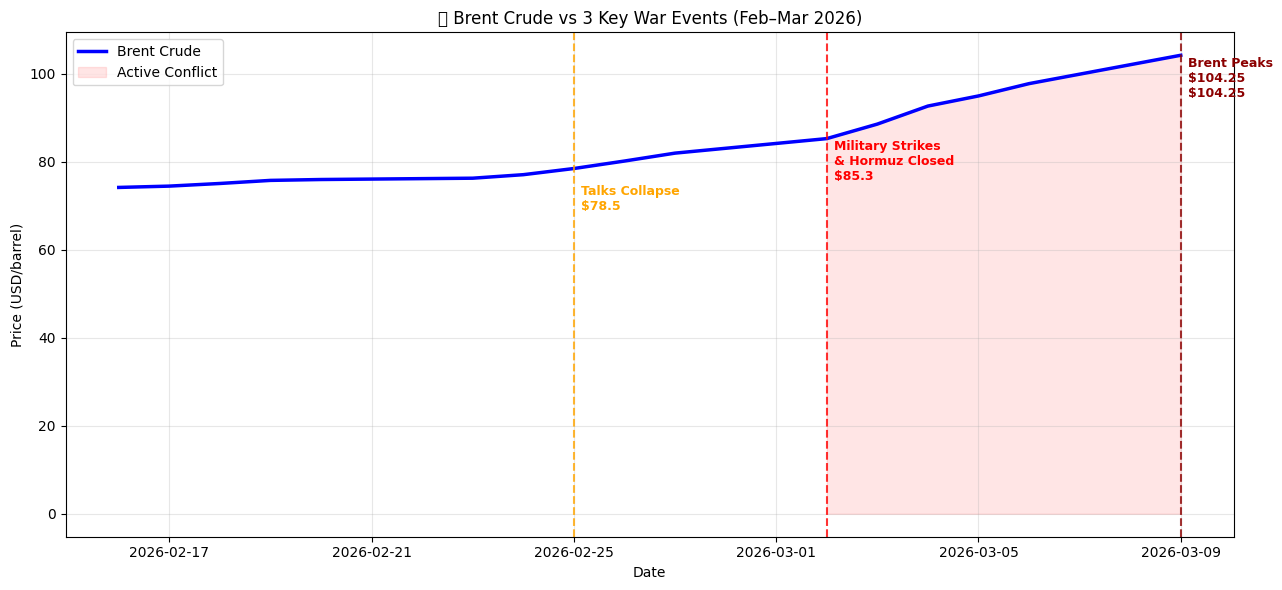

In [27]:
# Clean timeline — 3 key events only
fig, ax = plt.subplots(figsize=(13, 6))

# Brent price line
ax.plot(crude["Date"], crude["Brent_USD"],
        color="blue", linewidth=2.5, label="Brent Crude")

# 3 key events only
key_events = {
    "2026-02-25": ("Talks Collapse", 78.50),
    "2026-03-02": ("Military Strikes\n& Hormuz Closed", 85.30),
    "2026-03-09": ("Brent Peaks\n$104.25", 104.25)
}

colors = ["orange", "red", "darkred"]

for (date, (label, price)), color in zip(key_events.items(), colors):
    ax.axvline(x=pd.Timestamp(date),
               color=color, linestyle="--",
               linewidth=1.5, alpha=0.8)
    ax.annotate(f"{label}\n${price}",
                xy=(pd.Timestamp(date), price),
                xytext=(5, -30),
                textcoords="offset points",
                fontsize=9, color=color,
                fontweight="bold")

ax.fill_between(crude["Date"], crude["Brent_USD"],
                where=crude["Phase"]=="Active Conflict",
                alpha=0.1, color="red", label="Active Conflict")

ax.set_title("🛢️ Brent Crude vs 3 Key War Events (Feb–Mar 2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD/barrel)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

$$\textbf{Key Finding:}\ \text{The Hormuz closure triggered a}\ \$18.95\text{/barrel jump in just 7 trading days}$$

$$\text{— nearly } 3\times \text{ larger than the } \$6.80 \text{ jump caused by talks collapse —}$$

$$\text{proving supply disruption impacts markets more severely than diplomatic failure.}$$

$$\small\textit{Source: crude\_oil\_daily.csv}$$



$$\textbf{Chart Note:}$$

$$\text{The shaded } \color{red}{\textbf{red area}} \text{ represents the } \textbf{Active Conflict} \text{ phase starting March 2}^{nd}$$

$$\text{During this period, Brent crude jumped from } \$85.30 \rightarrow \$104.25$$

$$\Delta = \$18.95\text{/barrel increase in just 7 trading days}$$

$$\small\textit{(Source: crude\_oil\_daily.csv)}$$

**Which country was hit hardest by the war?**

In [28]:
# EDA Step 1: Which country had highest price increase?
print("Top 5 Most Affected Countries:")
print(prices[["Country", "Pct_Increase"]].sort_values("Pct_Increase", ascending=False).head())

Top 5 Most Affected Countries:
         Country  Pct_Increase
0       Pakistan         20.66
7           Iran          6.67
8   Saudi Arabia          6.45
13           USA          5.88
10         China          5.00


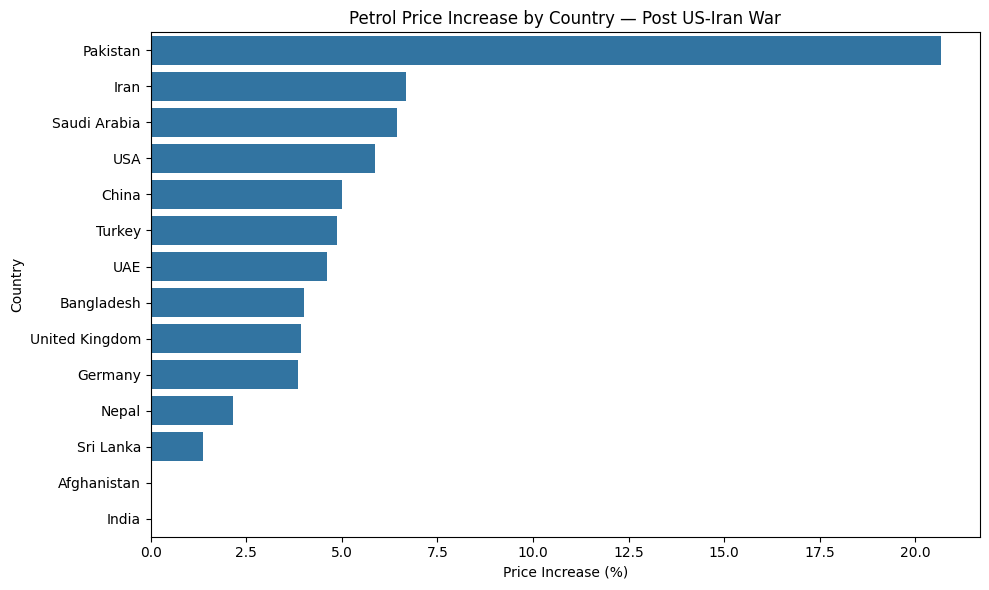

In [29]:
# Sort the data from highest to lowest before plotting
prices_sorted = prices.sort_values("Pct_Increase", ascending=False)

# Now plot with sorted data
plt.figure(figsize=(10, 6))
sns.barplot(data=prices_sorted, x="Pct_Increase", y="Country")
plt.title("Petrol Price Increase by Country — Post US-Iran War")
plt.xlabel("Price Increase (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

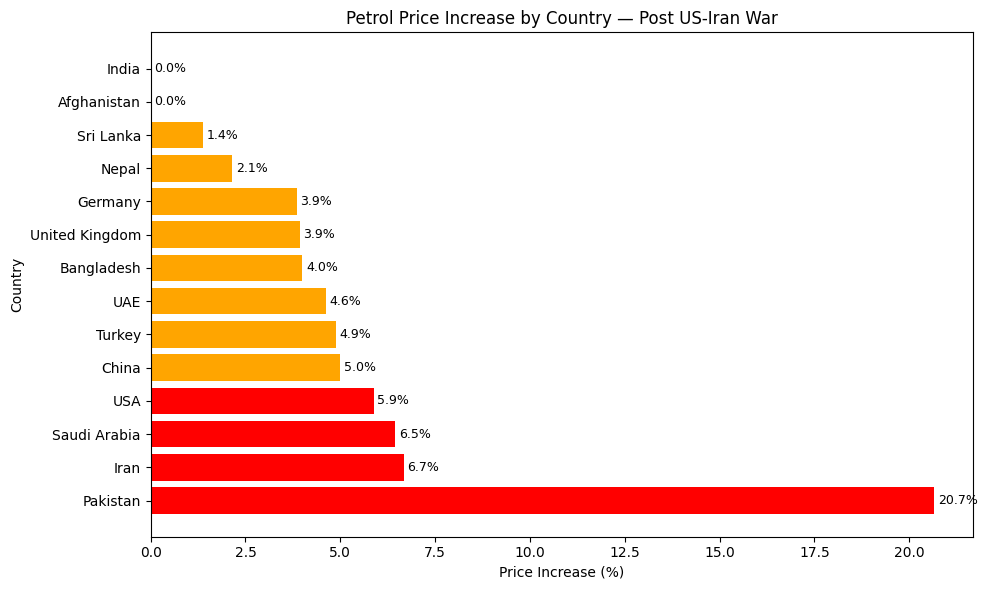

In [30]:
# Improved chart with colors and value labels
plt.figure(figsize=(10, 6))

# Create color list — red if increase > 5%, orange if > 0%, green if 0%
colors = ["red" if x > 5 else "orange" if x > 0 else "green"
          for x in prices_sorted["Pct_Increase"]]

# Plot bar chart
bars = plt.barh(prices_sorted["Country"], prices_sorted["Pct_Increase"], color=colors)

# Add value labels on each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f"{width:.1f}%", va="center", fontsize=9)

plt.title("Petrol Price Increase by Country — Post US-Iran War")
plt.xlabel("Price Increase (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

$$\textbf{📊 Insight 1: Most Affected Country}$$

$$\rule{12cm}{0.4pt}$$

$$\underbrace{\text{Pakistan}}_{\color{red}{\textbf{Hardest Hit}}} \Rightarrow \textbf{85\%} \text{ of oil is imported}$$

$$\underbrace{\text{Hormuz Closure}}_{\text{March 1st, 2026}} \Rightarrow \color{red}{\textbf{Supply Disrupted}}$$

$$\therefore \text{Petrol Prices} \uparrow \color{red}{\textbf{+20.66\%}} \text{ overnight}$$

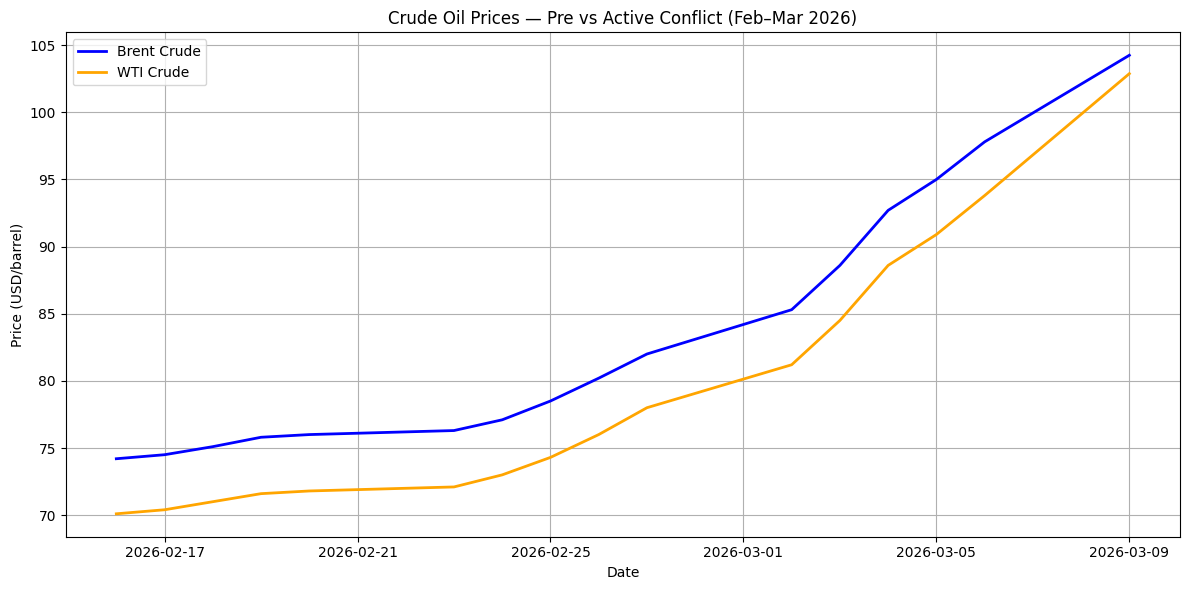

In [31]:
# Chart 2: Crude oil price timeline
plt.figure(figsize=(12, 6))

# Plot Brent crude price line
plt.plot(crude["Date"], crude["Brent_USD"],
         color="blue", label="Brent Crude", linewidth=2)

# Plot WTI crude price line
plt.plot(crude["Date"], crude["WTI_USD"],
         color="orange", label="WTI Crude", linewidth=2)

plt.title("Crude Oil Prices — Pre vs Active Conflict (Feb–Mar 2026)")
plt.xlabel("Date")
plt.ylabel("Price (USD/barrel)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

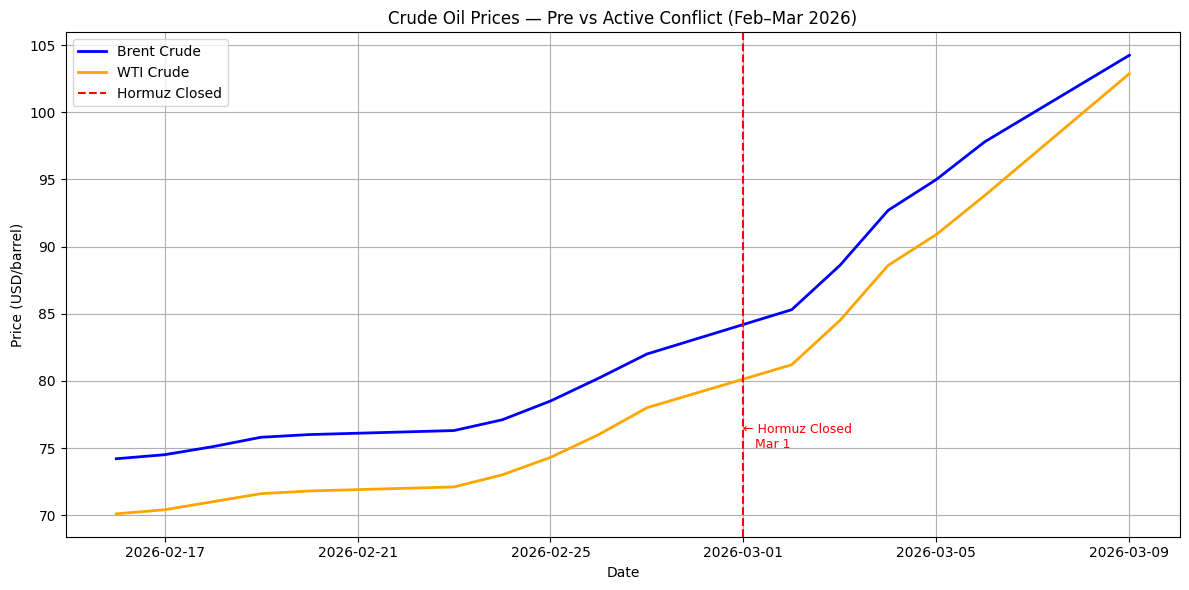

In [32]:
# Improved Chart 2: With conflict start marker
plt.figure(figsize=(12, 6))
plt.plot(crude["Date"], crude["Brent_USD"],
         color="blue", label="Brent Crude", linewidth=2)
plt.plot(crude["Date"], crude["WTI_USD"],
         color="orange", label="WTI Crude", linewidth=2)
# Add a vertical red line marking conflict start
plt.axvline(x=pd.Timestamp("2026-03-01"),
            color="red", linestyle="--", label="Hormuz Closed")
# Add text annotation
plt.text(pd.Timestamp("2026-03-01"), 75,
         "← Hormuz Closed\n   Mar 1", color="red", fontsize=9)
plt.title("Crude Oil Prices — Pre vs Active Conflict (Feb–Mar 2026)")
plt.xlabel("Date")
plt.ylabel("Price (USD/barrel)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

$$\textbf{📈 Insight 2: Brent Crude Price Spike}$$

$$\rule{12cm}{0.4pt}$$

$$\underbrace{\text{Iran closes Strait of Hormuz}}_{\text{March 1st, 2026}} \Rightarrow \color{red}{\textbf{Brent Crude}} \uparrow \color{red}{\textbf{+40.5\%}} \text{ in just 16 days}$$

$$\rule{12cm}{0.4pt}$$

$$\textbf{Impact:} \quad \text{20\% of } \textbf{Global Oil Supply} \color{red}{\textbf{ Disrupted}}$$

$$\therefore \text{Biggest price spike since } \textbf{2022}$$

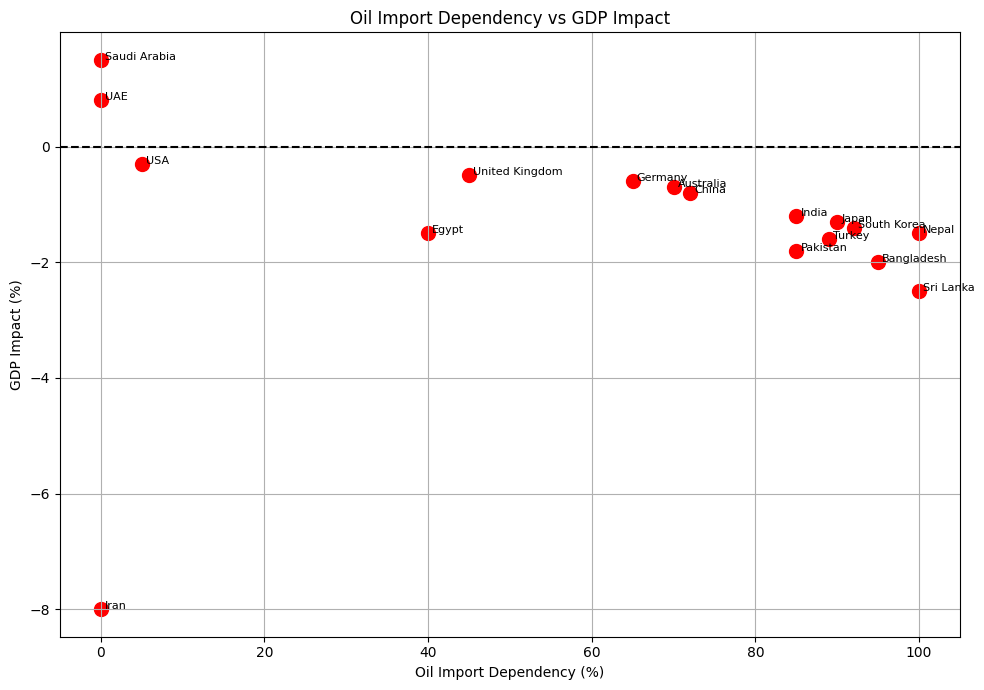

In [34]:
# Chart 3: Oil Import Dependency vs GDP Impact
plt.figure(figsize=(10, 7))

plt.scatter(impact["Oil_Import_Pct"],
            impact["GDP_Impact_Pct"],
            color="red", s=100)

# Add country name labels on each dot
for i, row in impact.iterrows():
    plt.text(row["Oil_Import_Pct"] + 0.5,
             row["GDP_Impact_Pct"],
             row["Country"], fontsize=8)

plt.title("Oil Import Dependency vs GDP Impact")
plt.xlabel("Oil Import Dependency (%)")
plt.ylabel("GDP Impact (%)")
plt.axhline(y=0, color="black", linestyle="--")
plt.grid(True)
plt.tight_layout()
plt.show()

### 🤖 **Step 5: Machine Learning — Linear Regression**
Building a regression model to predict GDP impact
from oil import dependency.

In [35]:
# Import machine learning library
from sklearn.linear_model import LinearRegression
import numpy as np

# Step 1: Prepare our data
X = impact[["Oil_Import_Pct"]]  # Input  (what we know)
y = impact["GDP_Impact_Pct"]    # Output (what we want to predict)

# Step 2: Create and train the model
model = LinearRegression()
model.fit(X, y)

# Step 3: See the results
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: -1.2690954275869428
Slope: -0.0017670645992468252


In [36]:
# Predict GDP impact for Pakistan
pakistan_import = [[85]]
prediction = model.predict(pakistan_import)
print("Predicted GDP impact for Pakistan:", prediction[0])

Predicted GDP impact for Pakistan: -1.419295918522923


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [37]:
from sklearn.metrics import r2_score, mean_absolute_error

# Make predictions for all countries
y_pred = model.predict(X)

# Check accuracy
r2  = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("R² Score:", round(r2, 4))
print("MAE:", round(mae, 4))

R² Score: 0.0012
MAE: 1.0726


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


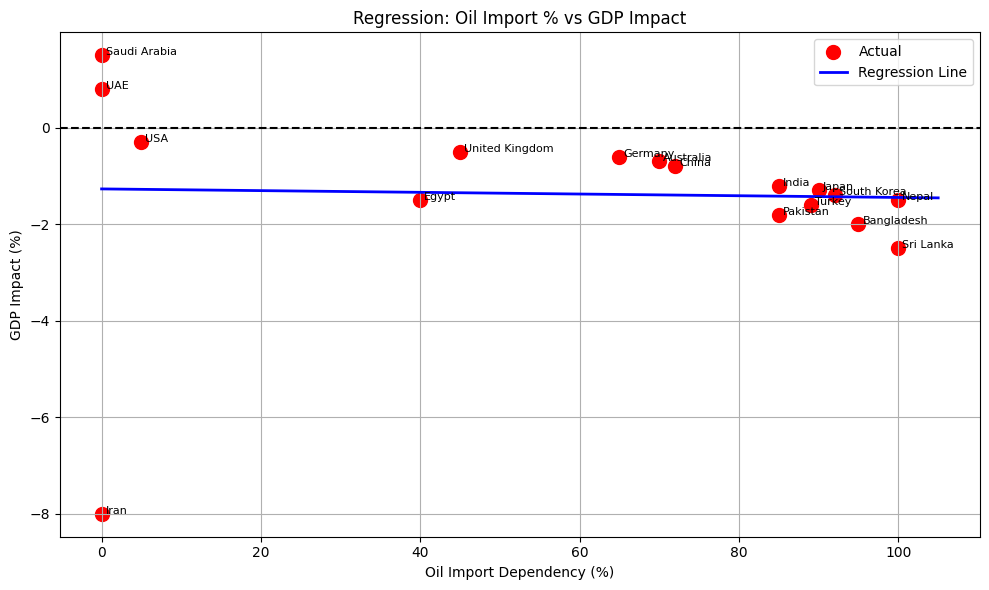

In [38]:
# Plot regression line over scatter plot
plt.figure(figsize=(10, 6))

# Original data points
plt.scatter(impact["Oil_Import_Pct"], impact["GDP_Impact_Pct"],
            color="red", s=100, label="Actual")

# Regression line
x_line = np.linspace(0, 105, 100).reshape(-1, 1)
plt.plot(x_line, model.predict(x_line),
         color="blue", linewidth=2, label="Regression Line")

# Country labels
for i, row in impact.iterrows():
    plt.text(row["Oil_Import_Pct"] + 0.5, row["GDP_Impact_Pct"],
             row["Country"], fontsize=8)

plt.axhline(y=0, color="black", linestyle="--")
plt.title("Regression: Oil Import % vs GDP Impact")
plt.xlabel("Oil Import Dependency (%)")
plt.ylabel("GDP Impact (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

$$\textbf{📉 Insight 3: Regression Model Accuracy}$$

$$\rule{12cm}{0.4pt}$$

$$\textbf{Model Result:} \quad R^2 = \color{red}{\textbf{0.0012}} \Rightarrow \color{red}{\textbf{Low Accuracy}}$$

$$\textbf{Reason:} \quad \text{Only } \underbrace{\textbf{1 variable}}_{\text{Oil Import Dependency}} \text{ used in model}$$

$$\rule{12cm}{0.4pt}$$

$$\textbf{In Reality, GDP is affected by:}$$

$$\texttt{Government Policy} \ | \ \texttt{Foreign Reserves} \ | \ \texttt{Currency Strength} \ | \ \texttt{Population Size}$$

$$\rule{12cm}{0.4pt}$$

$$\therefore \underbrace{\text{1 Variable}}_{\color{red}{R^2 = 0.0012}} \ll \underbrace{\text{Multiple Variables}}_{\color{green}{\textbf{Better Accuracy}}}$$

In [39]:
# Project Summary Statistics
print("=" * 50)
print("PROJECT SUMMARY")
print("=" * 50)
print(f"Countries Analysed:      {len(prices)}")
print(f"Trading Days Tracked:    {len(crude)}")
print(f"War Events Recorded:     {len(timeline)}")
print(f"Highest Price Increase:  {prices['Pct_Increase'].max():.2f}%")
print(f"Most Affected Country:   {prices.loc[prices['Pct_Increase'].idxmax(), 'Country']}")
print(f"Brent High:              ${crude['Brent_USD'].max()}")
print(f"Brent Low:               ${crude['Brent_USD'].min()}")
print(f"Brent Increase:          {((crude['Brent_USD'].max() - crude['Brent_USD'].min()) / crude['Brent_USD'].min() * 100):.1f}%")
print("=" * 50)

PROJECT SUMMARY
Countries Analysed:      14
Trading Days Tracked:    16
War Events Recorded:     20
Highest Price Increase:  20.66%
Most Affected Country:   Pakistan
Brent High:              $104.25
Brent Low:               $74.2
Brent Increase:          40.5%


## 🎯 **Step 6: Country Vulnerability Scorecard**
Creating a unique composite score ranking all 17 countries
by overall economic vulnerability using 4 weighted factors:
Oil Import %, GDP Impact, Inflation Risk, Stock Market Change.

In [40]:
# ── Country Vulnerability Scorecard ──────────────────
# Step 1: Map inflation risk to numbers
risk_map = {
    "Extreme"   : 5,
    "Very High" : 4,
    "High"      : 3,
    "Moderate"  : 2,
    "Low"       : 1
}

# Convert inflation risk words to numbers
impact["Inflation_Score"] = impact["Inflation_Risk"].map(risk_map)

# Check it worked
print(impact[["Country", "Inflation_Risk", "Inflation_Score"]].head())

      Country Inflation_Risk  Inflation_Score
0    Pakistan      Very High                4
1       India           High                3
2  Bangladesh      Very High                4
3   Sri Lanka      Very High                4
4       Nepal           High                3


In [41]:
# Step 2: Normalize all factors to 0-100 scale
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 100))

# Factors where HIGHER value = MORE vulnerable
impact["Import_Scaled"] = scaler.fit_transform(
    impact[["Oil_Import_Pct"]])

impact["Inflation_Scaled"] = scaler.fit_transform(
    impact[["Inflation_Score"]])

# Factors where LOWER value = MORE vulnerable
impact["GDP_Scaled"] = scaler.fit_transform(
    impact[["GDP_Impact_Pct"]]) * -1 + 100

impact["Stock_Scaled"] = scaler.fit_transform(
    impact[["Stock_Market_Change"]]) * -1 + 100

print("Scaling done!")
print(impact[["Country","Import_Scaled","GDP_Scaled",
              "Inflation_Scaled","Stock_Scaled"]].head())

Scaling done!
      Country  Import_Scaled  GDP_Scaled  Inflation_Scaled  Stock_Scaled
0    Pakistan           85.0   34.736842              75.0     21.739130
1       India           85.0   28.421053              50.0     13.768116
2  Bangladesh           95.0   36.842105              75.0     18.840580
3   Sri Lanka          100.0   42.105263              75.0     27.536232
4       Nepal          100.0   31.578947              50.0     11.594203


In [42]:
# Step 3: Calculate final vulnerability score
# Equal weight to all 4 factors (25% each)
impact["Vulnerability_Score"] = (
    impact["Import_Scaled"] * 0.25 +
    impact["GDP_Scaled"] * 0.25 +
    impact["Inflation_Scaled"] * 0.25 +
    impact["Stock_Scaled"] * 0.25
)

# Round to 2 decimal places
impact["Vulnerability_Score"] = impact["Vulnerability_Score"].round(2)

# Sort from most to least vulnerable
scorecard = impact[["Country", "Vulnerability_Score"]].sort_values(
    "Vulnerability_Score", ascending=False).reset_index(drop=True)

# Add rank column
scorecard["Rank"] = scorecard.index + 1

print(scorecard)

           Country  Vulnerability_Score  Rank
0             Iran                75.00     1
1        Sri Lanka                61.16     2
2       Bangladesh                56.42     3
3           Turkey                55.14     4
4         Pakistan                54.12     5
5      South Korea                51.83     6
6            Japan                49.43     7
7            Nepal                48.29     8
8            India                44.30     9
9            Egypt                41.72    10
10       Australia                39.41    11
11           China                32.66    12
12         Germany                32.19    13
13  United Kingdom                25.84    14
14             USA                13.69    15
15             UAE                 2.39    16
16    Saudi Arabia                 0.00    17


/tmp/ipykernel_23087/1692240847.py:19: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


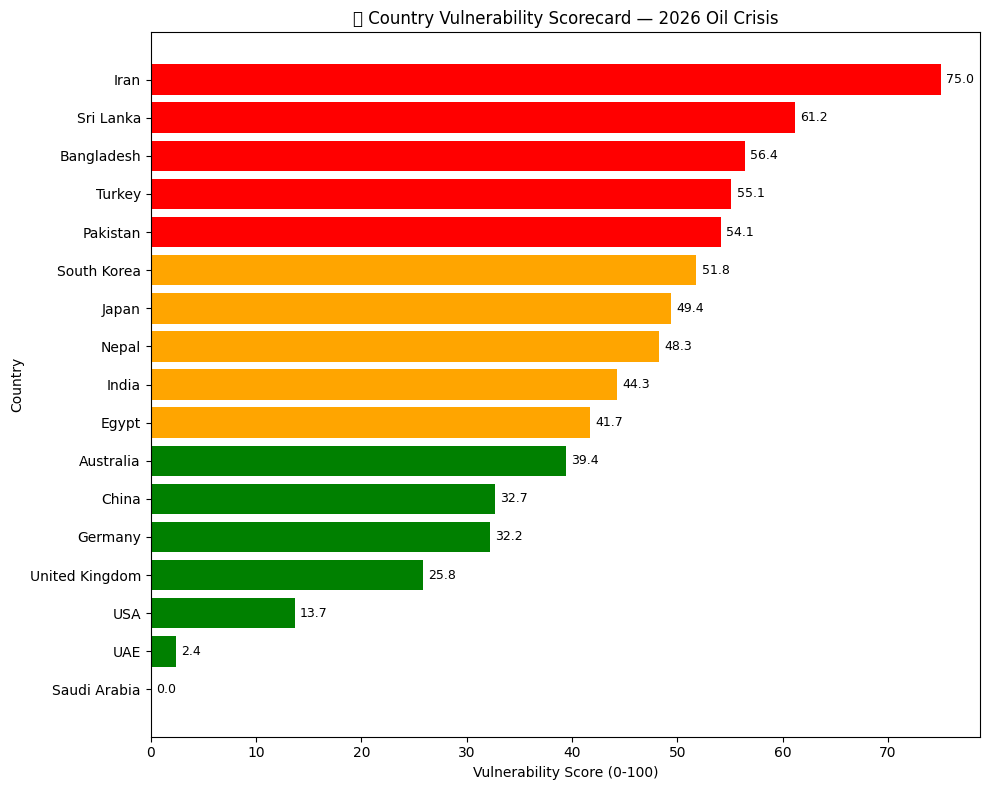

In [43]:
# Visualise vulnerability scorecard
plt.figure(figsize=(10, 8))

colors = ["red" if r <= 5 else "orange" if r <= 10 else "green"
          for r in scorecard["Rank"]]

bars = plt.barh(scorecard["Country"][::-1],
                scorecard["Vulnerability_Score"][::-1],
                color=colors[::-1])

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f"{width:.1f}", va="center", fontsize=9)

plt.title("🌍 Country Vulnerability Scorecard — 2026 Oil Crisis")
plt.xlabel("Vulnerability Score (0-100)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

$$\textbf{🌍 Insight — India Vulnerability Score:}$$

$$\rule{12cm}{0.4pt}$$

$$\underbrace{\text{India}}_{\color{orange}{\textbf{Orange Score}}} \Rightarrow \textbf{85\%} \text{ Oil Import Dependency}$$

$$\color{green}{\textbf{✅ Price Freeze Policies}} \Rightarrow \text{Successfully reduced damage}$$

$$\color{red}{\textbf{⚠️ Structural Exposure}} \Rightarrow \text{Underlying risk remains unchanged}$$

$$\rule{12cm}{0.4pt}$$

$$\therefore \text{Policy response} \underbrace{\color{green}{\textbf{ reduced the damage}}}_{\text{Short Term}} \text{ but NOT } \underbrace{\color{red}{\textbf{the underlying risk}}}_{\text{Long Term}}$$

## 🔮 **Step 7: What-If Scenario Analysis**
Predicting GDP impact at $120, $150 and $200 per barrel
to understand future risk exposure for each country.

In [44]:
# What-If Scenario Analysis
scenarios = {
    "$120/barrel": (120 - 104) / 104,
    "$150/barrel": (150 - 104) / 104,
    "$200/barrel": (200 - 104) / 104
}
# Current GDP impacts
base_gdp = impact[["Country", "GDP_Impact_Pct", "Oil_Import_Pct"]].copy()

# Calculate additional damage for each scenario
for scenario, multiplier in scenarios.items():
    base_gdp[scenario] = (
        base_gdp["GDP_Impact_Pct"] * (1 + multiplier)
    ).round(2)

# Show results
print(base_gdp[["Country", "GDP_Impact_Pct",
                "$120/barrel", "$150/barrel",
                "$200/barrel"]])

           Country  GDP_Impact_Pct  $120/barrel  $150/barrel  $200/barrel
0         Pakistan            -1.8        -2.08        -2.60        -3.46
1            India            -1.2        -1.38        -1.73        -2.31
2       Bangladesh            -2.0        -2.31        -2.88        -3.85
3        Sri Lanka            -2.5        -2.88        -3.61        -4.81
4            Nepal            -1.5        -1.73        -2.16        -2.88
5            China            -0.8        -0.92        -1.15        -1.54
6            Japan            -1.3        -1.50        -1.88        -2.50
7      South Korea            -1.4        -1.62        -2.02        -2.69
8           Turkey            -1.6        -1.85        -2.31        -3.08
9          Germany            -0.6        -0.69        -0.87        -1.15
10  United Kingdom            -0.5        -0.58        -0.72        -0.96
11             USA            -0.3        -0.35        -0.43        -0.58
12    Saudi Arabia             1.5    

$$\textbf{🔮 Scenario Finding: \ \$200/barrel}$$

$$\rule{12cm}{0.4pt}$$

$$\underbrace{\text{Pakistan}}_{\color{red}{\textbf{Import Dependent}}} \Rightarrow \text{GDP} \color{red}{\textbf{\ -3.46\%}} \Rightarrow \text{Millions pushed into poverty}$$

$$\underbrace{\text{Saudi Arabia}}_{\color{green}{\textbf{Oil Exporter}}} \Rightarrow \text{GDP} \color{green}{\textbf{\ +2.88\%}}$$

$$\underbrace{\text{UAE}}_{\color{green}{\textbf{Oil Exporter}}} \Rightarrow \text{GDP} \color{green}{\textbf{\ +1.44\%}}$$

$$\rule{12cm}{0.4pt}$$

$$\therefore \text{The } \textbf{same oil crisis} \text{ that } \color{red}{\textbf{destroys}} \text{ import-dependent economies}$$

$$\text{simultaneously } \color{green}{\textbf{enriches}} \text{ oil exporters}$$

$$\textbf{📊 Data Finding:}$$

$$\text{Saudi Arabia GDP grew } \color{green}{\textbf{+1.5\%}} \text{ at } \$200\text{/barrel}$$

$$\small\textit{(Source: country\_impact.csv)}$$

$$\rule{12cm}{0.4pt}$$

$$\textbf{🌍 External Context:}$$

$$\underbrace{\text{Saudi Arabia}}_{\color{green}{\textbf{Profited}}} \quad \text{and} \quad \underbrace{\text{UAE}}_{\color{green}{\textbf{Profited}}} \Rightarrow \text{Alternative pipeline routes bypassed Strait of Hormuz}$$

$$\underbrace{\text{Iran}}_{\color{red}{\textbf{Could NOT Benefit}}} \Rightarrow \text{Military strikes destroyed infrastructure} \Rightarrow \text{Recovery impossible}$$

$$\therefore \text{Same oil crisis } \color{green}{\textbf{enriched exporters}} \text{ while } \color{red}{\textbf{destroying importers}}$$

In [45]:
# Export results for Power BI
from google.colab import files
# Save scorecard
scorecard.to_csv("vulnerability_scorecard.csv", index=False)
# Save what-if scenarios
base_gdp.to_csv("whatif_scenarios.csv", index=False)
print("Files ready for download!")
files.download("vulnerability_scorecard.csv")
files.download("whatif_scenarios.csv")

Files ready for download!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
# Download original dataset files for Power BI
import shutil
files.download(path + "/petrol_prices_comparison.csv")
files.download(path + "/country_impact.csv")
files.download(path + "/crude_oil_daily.csv")
files.download(path + "/war_timeline.csv")
files.download(path + "/pros_cons_analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>